In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import precision_score, confusion_matrix
from sklearn import tree

import warnings
warnings.filterwarnings('ignore')

import plotly.io as pio
pio.renderers.default = 'browser'

In [14]:
dataset = pd.read_csv("water_potability.csv")

In [16]:
dataset.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [18]:
dataset.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [76]:
data = pd.DataFrame(dataset["Potability"].value_counts().reset_index())
data.columns = ["Potability", 'counts']
fig = px.pie(data, values = 'counts', names = ["Not Potable", "Potable"], opacity = 0.8, hole = 0.35,
            labels = {"label": "Potability", "Potability": "Number of Samples"})
fig.update_layout(title = dict(text = "Pie of Potability features"))
fig.update_traces(textposition = "outside", textinfo = "percent+label")
fig.show()

In [54]:
print(data)

            count
Potability       
0            1998
1            1278


In [78]:
dataset.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


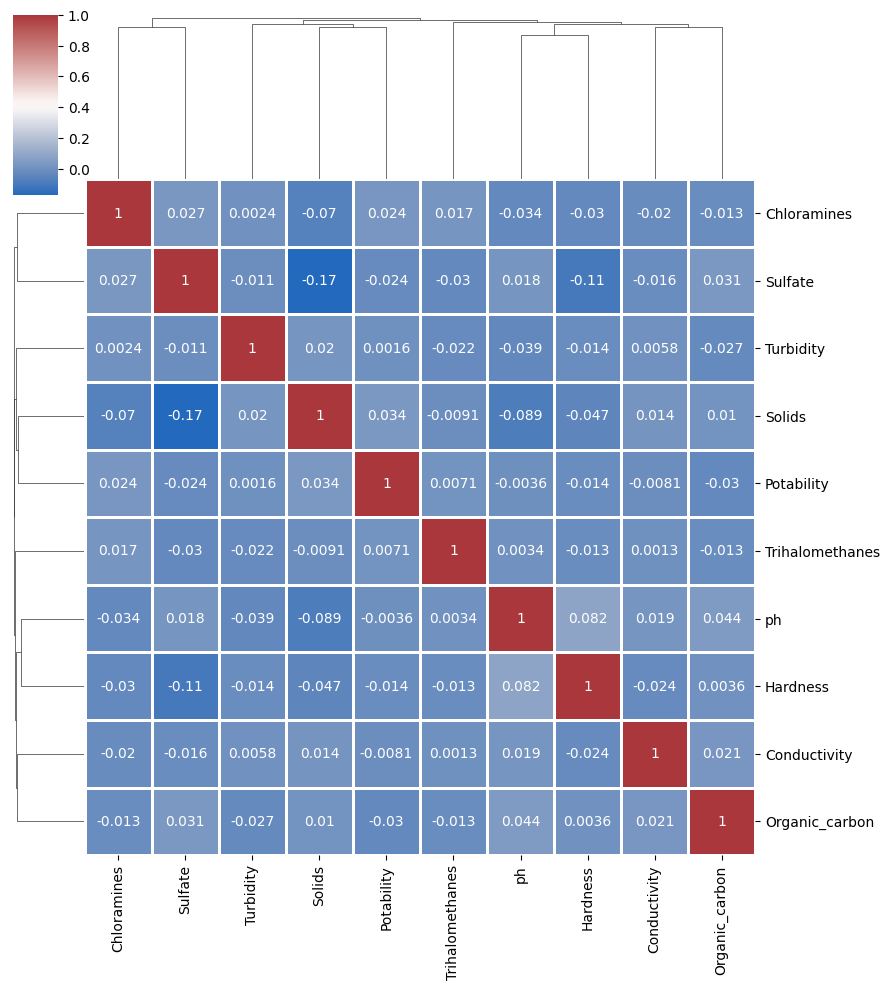

In [82]:
sns.clustermap(dataset.corr(), dendrogram_ratio=(0.1, 0.2),cmap = 'vlag', annot = True, linewidth = 0.8, figsize = (9, 10))
plt.show()

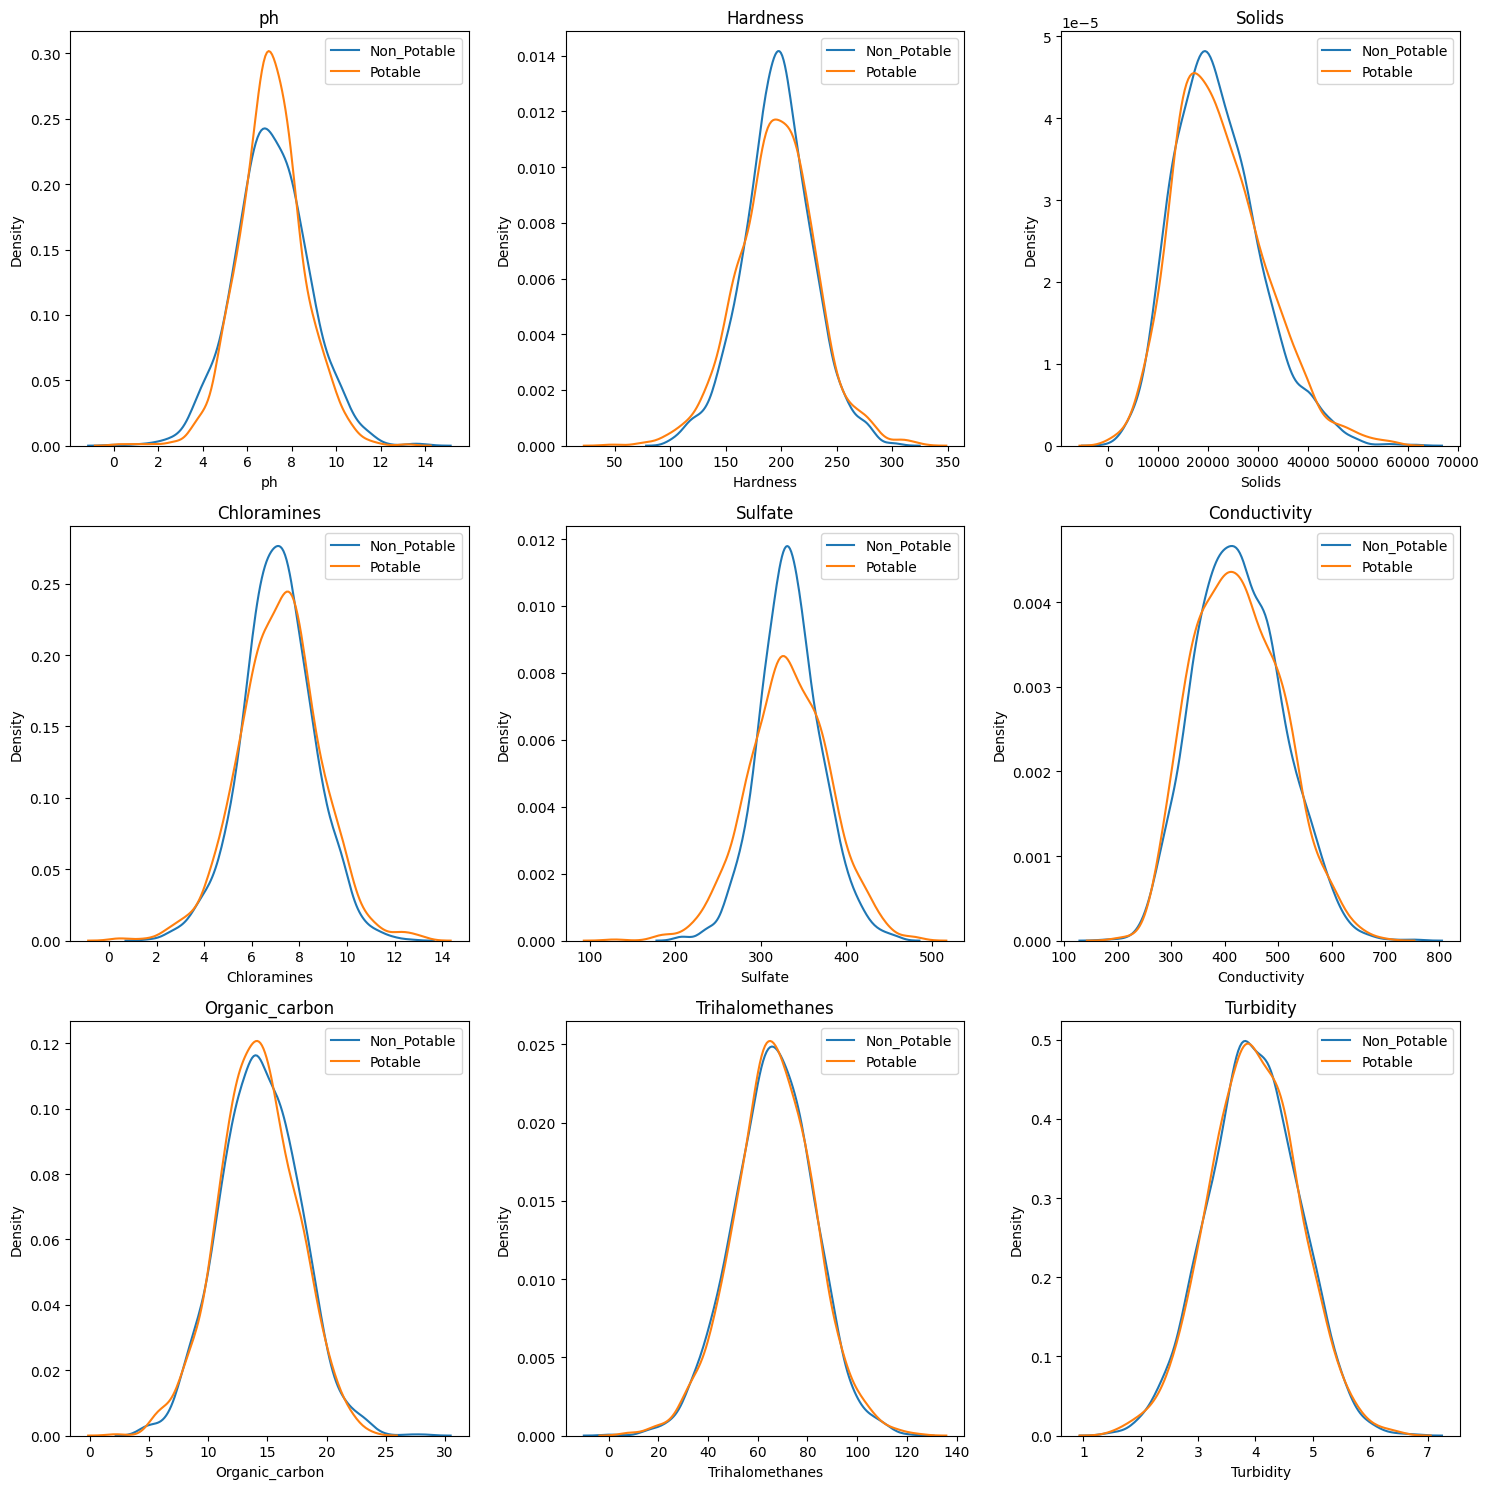

In [86]:
non_potable = dataset.query("Potability == 0")
potable = dataset.query("Potability == 1")

plt.figure(figsize = (15, 15))
for ax, col in enumerate(dataset.columns[:9]):
    plt.subplot(3, 3, ax + 1)
    plt.title(col)
    sns.kdeplot(x = non_potable[col], label = "Non_Potable")
    sns.kdeplot(x = potable[col], label = "Potable")
    plt.legend()

plt.tight_layout()

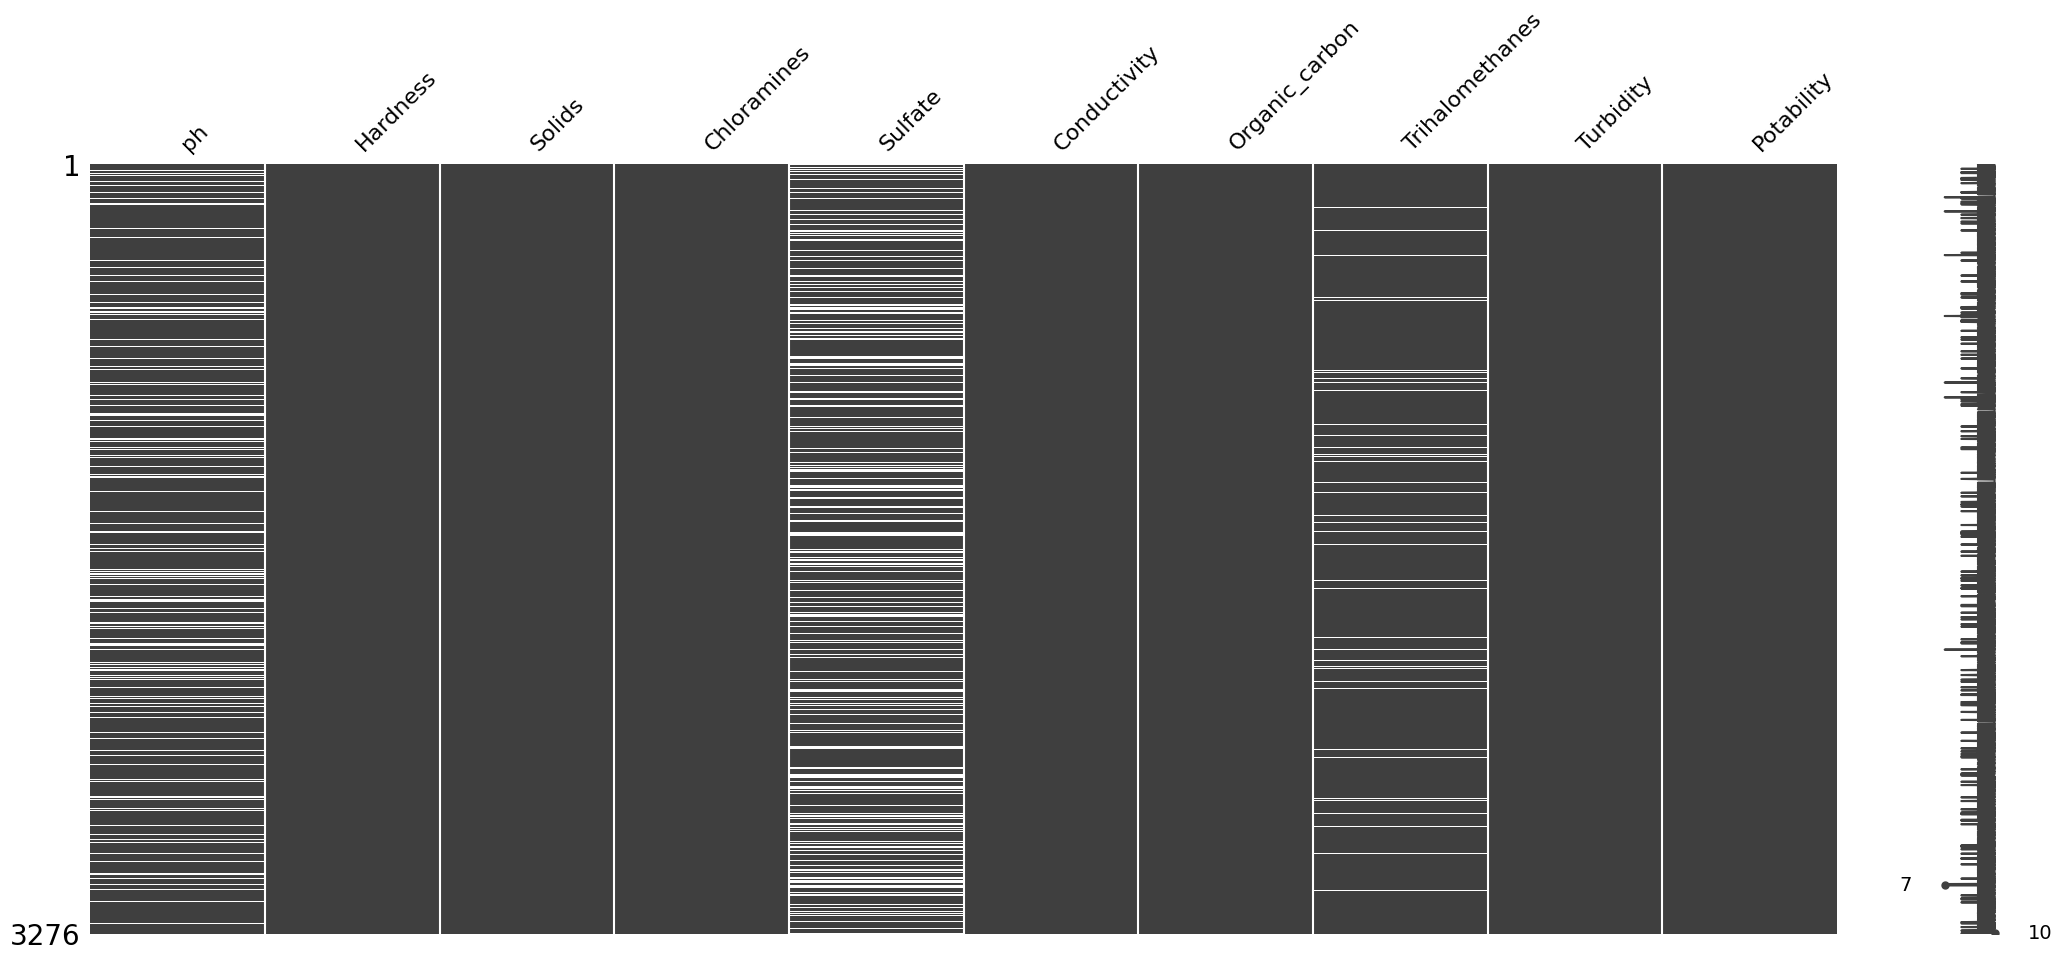

In [90]:
msno.matrix(dataset)
plt.show()

In [92]:
dataset.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [100]:
dataset["ph"].fillna(value = dataset["ph"].mean(), inplace = True)
dataset["Sulfate"].fillna(value = dataset["Sulfate"].mean(), inplace = True)
dataset["Trihalomethanes"].fillna(value = dataset['Trihalomethanes'].mean(), inplace = True)

In [102]:
dataset.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [104]:
X = dataset.drop("Potability", axis = 1).values
y = dataset["Potability"]

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (2293, 9)
X_test:  (983, 9)
y_train:  (2293,)
y_test:  (983,)


In [112]:
print(X_train)

[[1.15647865e-04 3.07780662e-03 4.70242250e-01 ... 1.72728637e-04
  1.03279864e-03 5.27278632e-05]
 [1.17650968e-04 2.75115257e-03 3.72816104e-01 ... 2.68028836e-04
  1.05355017e-03 1.04351684e-04]
 [1.15647865e-04 3.96600864e-03 4.78514062e-01 ... 8.86313646e-05
  1.08442485e-03 5.75330311e-05]
 ...
 [1.08291156e-04 3.05029627e-03 5.05315043e-01 ... 2.25647389e-04
  1.41690496e-03 5.70104104e-05]
 [1.43452064e-04 3.56104565e-03 2.64320232e-01 ... 2.67112024e-04
  7.69282037e-04 6.98078168e-05]
 [1.09398344e-04 3.23853257e-03 5.66347393e-01 ... 1.98876956e-04
  1.08442485e-03 6.13808878e-05]]


In [108]:
#min max normalization
X_train_min = np.min(X_train)
X_train_max = np.max(X_train)

X_train = (X_train - X_train_min)/(X_train_max - X_train_min)
X_test = (X_test - X_train_min)/(X_train_max - X_train_min)

In [110]:
print(X_train)

[[1.15647865e-04 3.07780662e-03 4.70242250e-01 ... 1.72728637e-04
  1.03279864e-03 5.27278632e-05]
 [1.17650968e-04 2.75115257e-03 3.72816104e-01 ... 2.68028836e-04
  1.05355017e-03 1.04351684e-04]
 [1.15647865e-04 3.96600864e-03 4.78514062e-01 ... 8.86313646e-05
  1.08442485e-03 5.75330311e-05]
 ...
 [1.08291156e-04 3.05029627e-03 5.05315043e-01 ... 2.25647389e-04
  1.41690496e-03 5.70104104e-05]
 [1.43452064e-04 3.56104565e-03 2.64320232e-01 ... 2.67112024e-04
  7.69282037e-04 6.98078168e-05]
 [1.09398344e-04 3.23853257e-03 5.66347393e-01 ... 1.98876956e-04
  1.08442485e-03 6.13808878e-05]]


In [114]:
models = [("DT", DecisionTreeClassifier(max_depth=3)),
         ("RD", RandomForestClassifier())]

In [116]:
score = []
matrix = []

for name, model in models:
    model.fit(X_train, y_train)
    classifier_result = model.predict(X_test)
    accuracy = precision_score(y_test, classifier_result)
    confusion_m = confusion_matrix(y_test, classifier_result)

    score.append((name, accuracy))
    matrix.append((name, confusion_m))

score
    

[('DT', 0.72), ('RD', 0.625615763546798)]

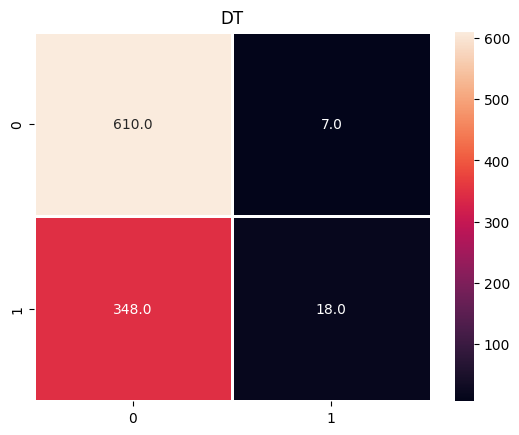

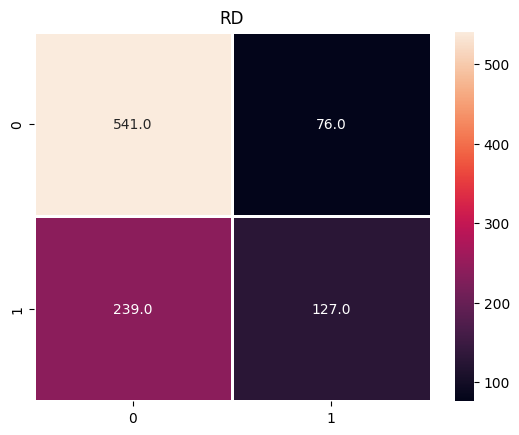

In [120]:
for name , i in matrix:
    plt.figure()
    sns.heatmap(i, annot = True, linewidth = 0.8, fmt = ".1f")
    plt.title(name)
    plt.show()

In [122]:
dt_clf = models[0][1]
dt_clf

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


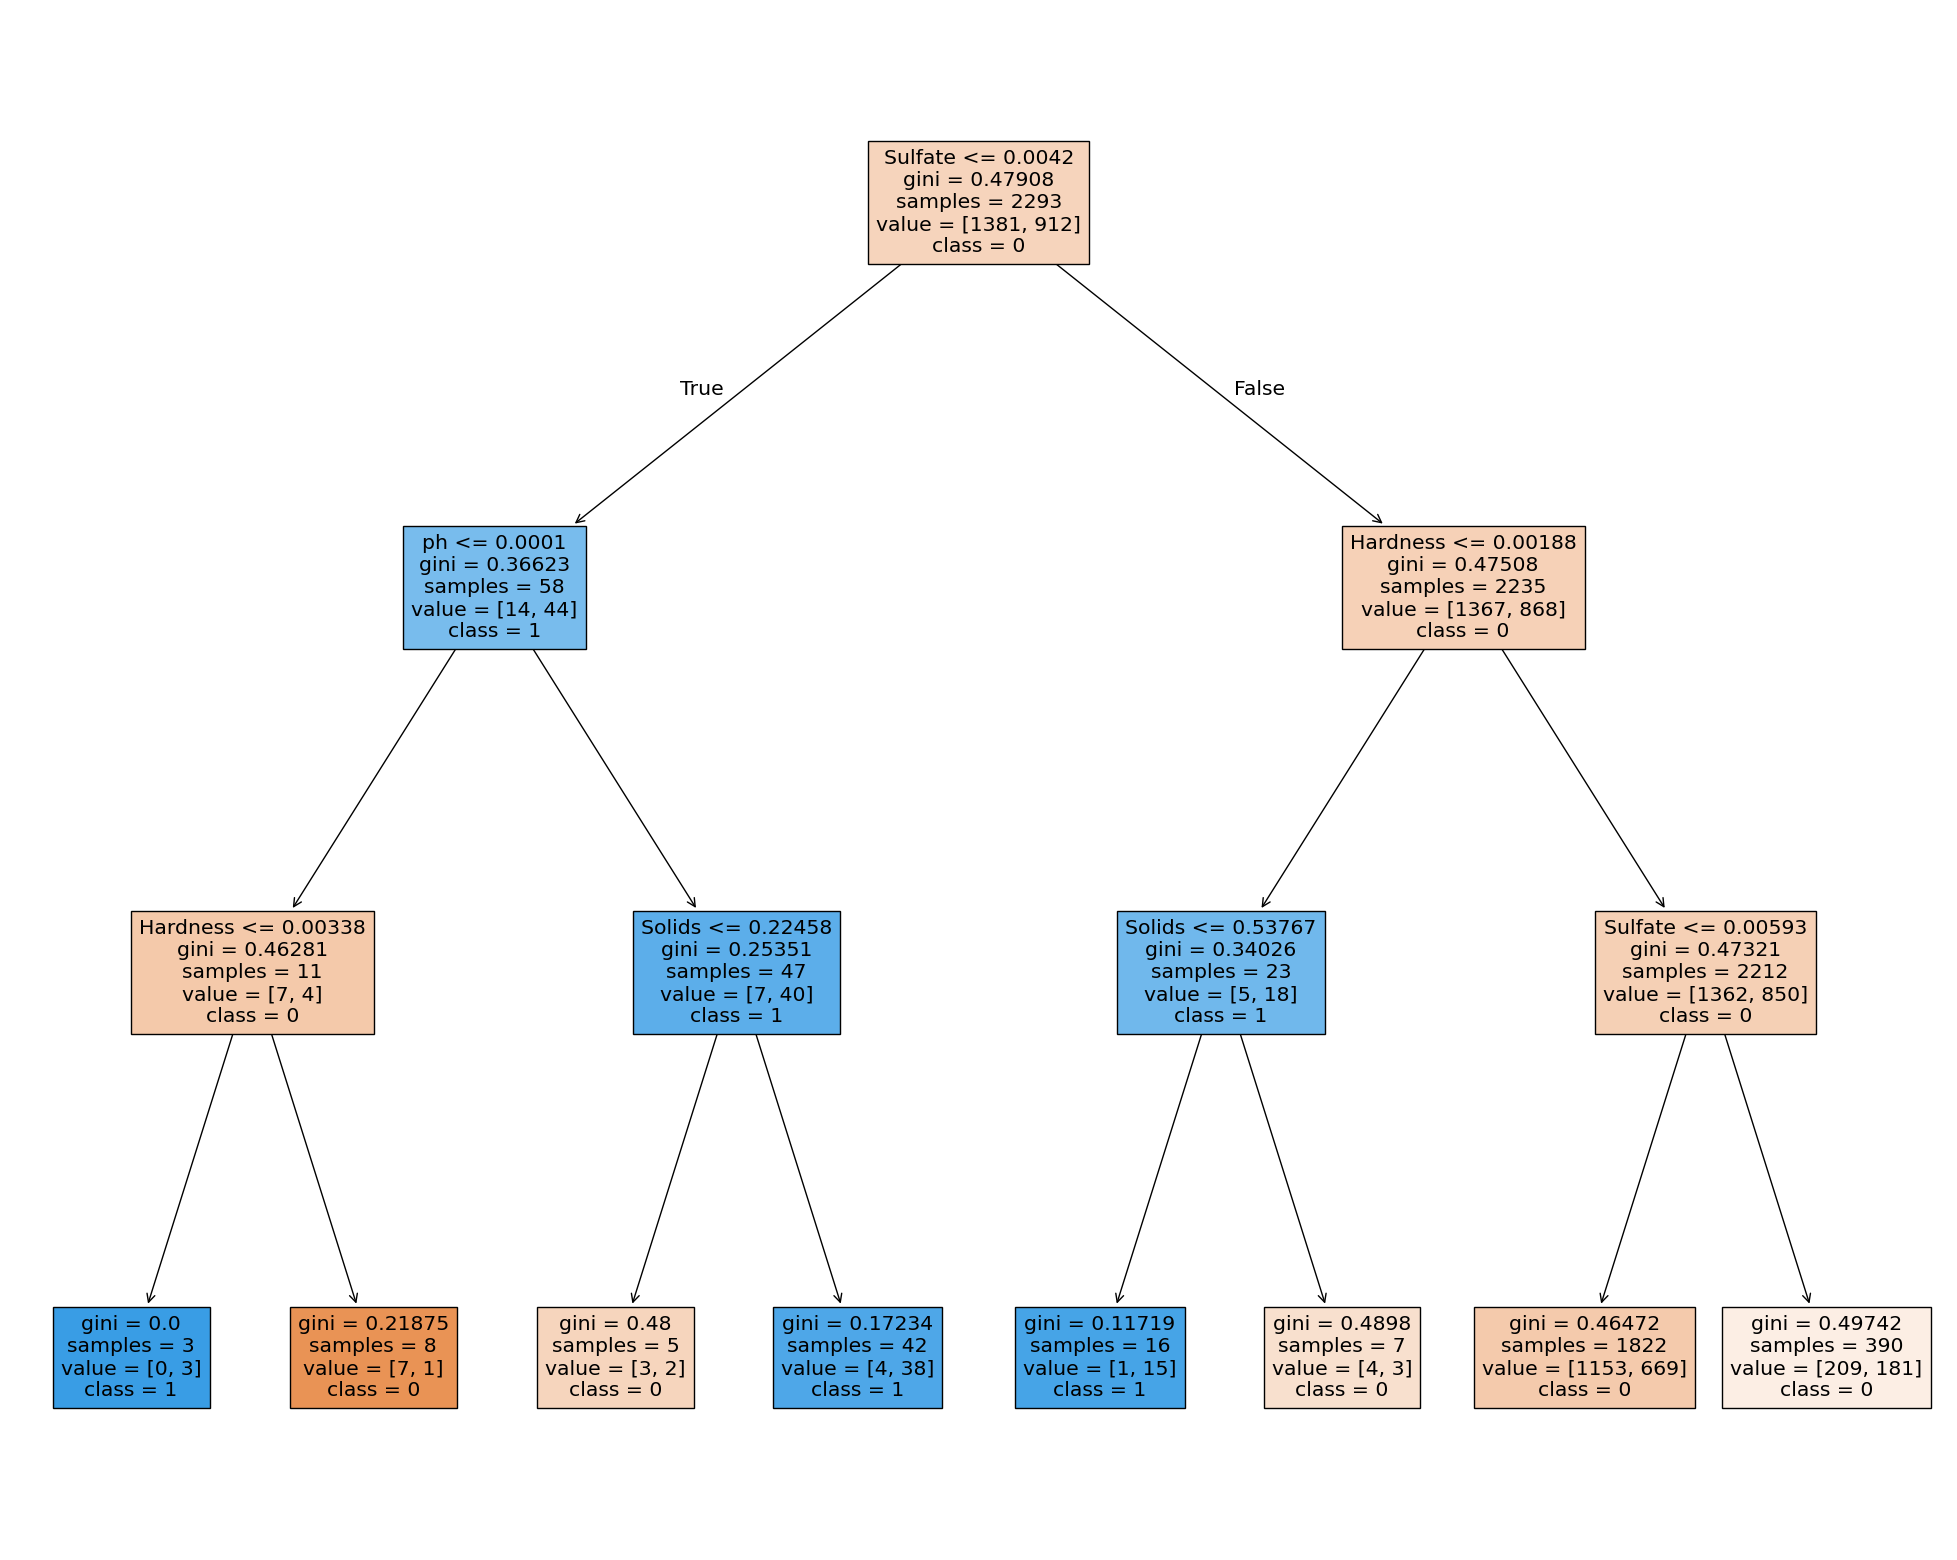

In [124]:
plt.figure(figsize = (25, 20))
tree.plot_tree(dt_clf,
              feature_names = dataset.columns.tolist()[:-1],
               class_names = ["0", "1"],
              filled = True,
              precision = 5)

plt.show()


In [126]:
model_params = {
    "Random Forest":
    {
        "model": RandomForestClassifier(),
        "params": 
        {
            "n_estimators": [10, 50, 100],
            "max_features": ["auto", "sqrt", "log2"],
            "max_depth":list(range(1, 21, 3))
        }
    }
}
model_params

{'Random Forest': {'model': RandomForestClassifier(),
  'params': {'n_estimators': [10, 50, 100],
   'max_features': ['auto', 'sqrt', 'log2'],
   'max_depth': [1, 4, 7, 10, 13, 16, 19]}}}

In [134]:
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 2)
score = []

for model_name, params in model_params.items():
    rs = RandomizedSearchCV(params["model"], params["params"], cv = cv, n_iter = 10)
    rs.fit(X, y)
    score.append([model_name, dict(rs.best_params_), rs.best_score_])
score

[['Random Forest',
  {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 16},
  0.672465555762428]]